In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import VotingClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# EDA

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,chest_pain_type,resting_bp,cholestoral,fasting_blood_sugar,restecg,max_hr,exang,oldpeak,slope,num_major_vessels,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


age - age of the person (in years)

sex - gender of the person (1 = male; 0 = female)

chest_pain_type - type of the chest pain:
 - Value 0: typical angina
 - Value 1: atypical angina
 - Value 2: non-anginal pain
 - Value 3: asymptomatic

resting_bp - blood pressure while resting (in mm Hg on admission to the hospital)

cholesterol - A person's serum cholesterol in mg/dl

fasting_blood_sugar - Blood sugar while fasting & [ > 120 mg/dl ] (1 = true; 0 = false)

restecg - ECG (electrocardiographic ) while resting:
 - Value 0: normal
 - Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
 - Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

max_hr - Maximum heart rate achieved

exang - exercise-induced angina (1 = yes; 0 = no)

Exercise-induced angina (AP) is a common complaint of cardiac patients, particularly when exercising in the cold. It usually happens during activity (exertion) and goes away with rest or angina medication. For example, pain, when walking uphill or in cold weather, maybe angina. Stable angina pain is predictable and usually similar to previous episodes of chest pain.

oldpeak - ST depression induced by exercise relative to rest

Exercise-induced ST segment depression is considered a reliable ECG finding for the diagnosis of obstructive coronary atherosclerosis. 
ST-segment depression is believed as a common electrocardiographic sign of myocardial ischemia during exercise testing. Ischemia is generally defined as oxygen deprivation due to reduced perfusion. ST segment depression less than 0.5 mm is accepted in all leads. ST segment depression 0.5 mm or more is considered pathological.

slope - the slope of the peak exercise ST segment:

 - Value 0: upsloping
 - Value 1: flat
 - Value 2: downsloping

num_major_vessels - no. of major vessels (0-3) colored by flourosopy

thal - thalassemia:
- 0: normal
- 1: fixed defect
- 2: reversable defect

People with thalassemia can get too much iron in their bodies, either from the disease or from frequent blood transfusions. Too much iron can result in damage to your heart, liver & endocrine system, which includes hormone-producing glands that regulate processes throughout your body.

target -
 - 0 = no disease
 - 1 = disease

In [3]:
df.shape

(303, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  303 non-null    int64  
 1   sex                  303 non-null    int64  
 2   chest_pain_type      303 non-null    int64  
 3   resting_bp           303 non-null    int64  
 4   cholestoral          303 non-null    int64  
 5   fasting_blood_sugar  303 non-null    int64  
 6   restecg              303 non-null    int64  
 7   max_hr               303 non-null    int64  
 8   exang                303 non-null    int64  
 9   oldpeak              303 non-null    float64
 10  slope                303 non-null    int64  
 11  num_major_vessels    303 non-null    int64  
 12  thal                 303 non-null    int64  
 13  target               303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.describe()

,age,sex,chest_pain_type,resting_bp,cholestoral,fasting_blood_sugar,restecg,max_hr,exang,oldpeak,slope,num_major_vessels,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.isnull().sum()

age                    0
sex                    0
chest_pain_type        0
resting_bp             0
cholestoral            0
fasting_blood_sugar    0
restecg                0
max_hr                 0
exang                  0
oldpeak                0
slope                  0
num_major_vessels      0
thal                   0
target                 0
dtype: int64

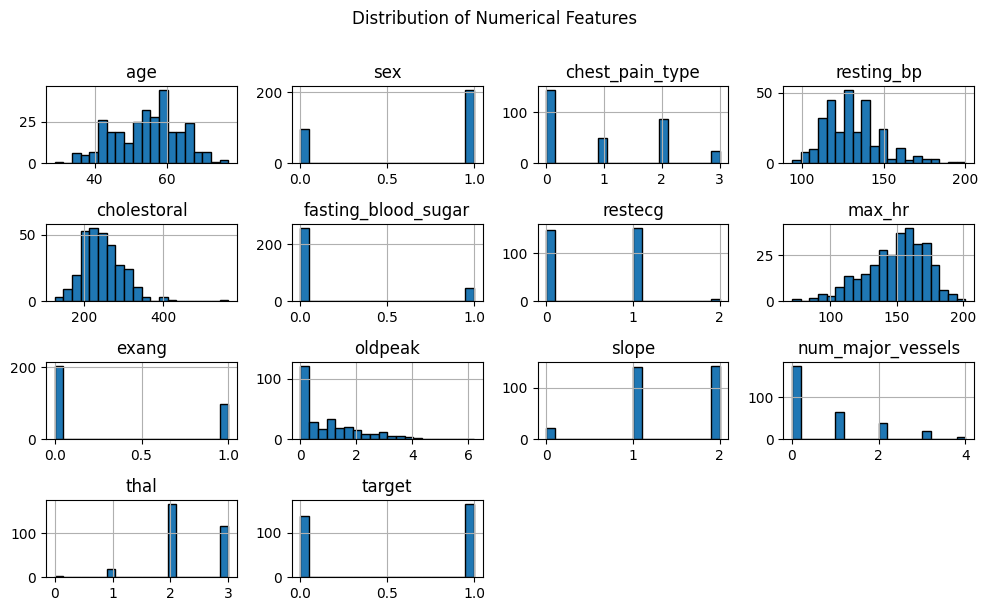

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(10, 6), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

In [8]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [9]:
df['target'].value_counts(normalize=True) * 100

target
1    54.455446
0    45.544554
Name: proportion, dtype: float64

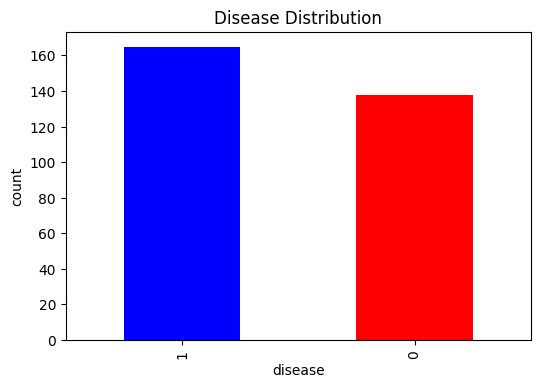

In [10]:
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Disease Distribution')
plt.xlabel('disease')
plt.ylabel('count')
plt.show()

In [11]:
df.duplicated().sum()

np.int64(1)

outliers in age: 0


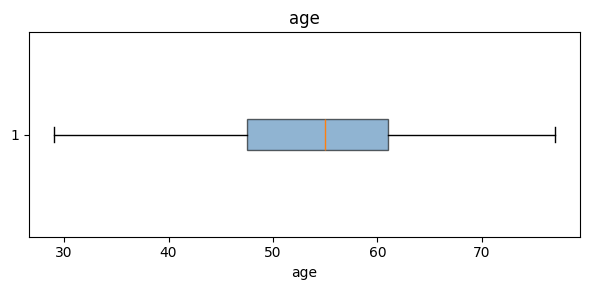

outliers in resting_bp: 9


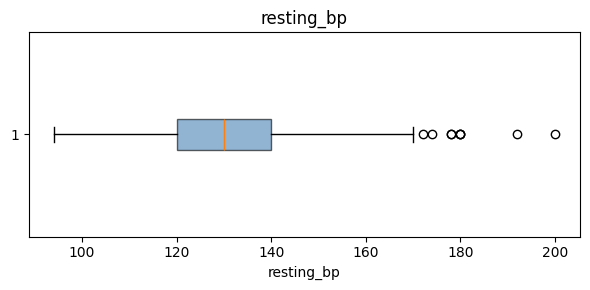

outliers in cholestoral: 5


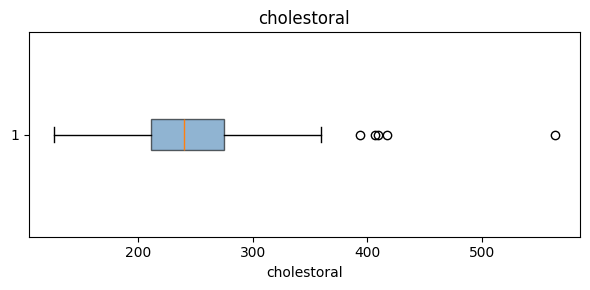

outliers in max_hr: 1


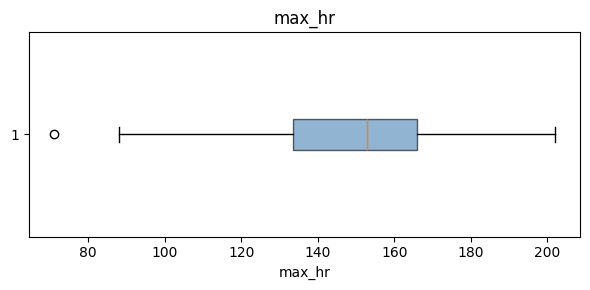

outliers in oldpeak: 5


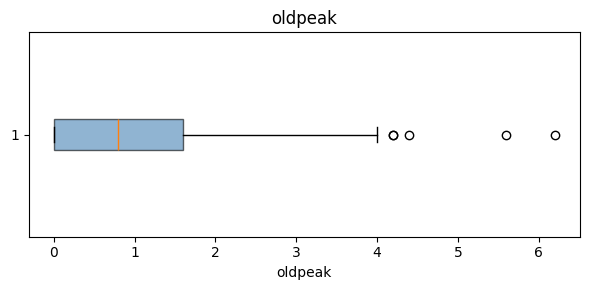

In [12]:
num_cols=["age","resting_bp","cholestoral","max_hr","oldpeak"]
for col in num_cols:
    Q1,Q3=df[col].quantile(0.25),df[col].quantile(0.75)
    IQR=Q3-Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers= df[(df[col] < lower) | (df[col] > upper)]
    print(f'outliers in {col}: {len(outliers)}')
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col], vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
    plt.title(col)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# Preprocessing

In [13]:
df.drop_duplicates(inplace=True)
df.duplicated().sum() 

np.int64(0)

In [14]:
X = df.drop("target", axis=1)
y = df["target"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,age,sex,chest_pain_type,resting_bp,cholestoral,fasting_blood_sugar,restecg,max_hr,exang,oldpeak,slope,num_major_vessels,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
203,68,1,2,180,274,1,0,150,1,1.6,1,0,3
197,67,1,0,125,254,1,1,163,0,0.2,1,2,3
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
177,64,1,2,140,335,0,1,158,0,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,41,1,0,110,172,0,0,158,0,0.0,2,0,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
271,61,1,3,134,234,0,1,145,0,2.6,1,2,2


In [16]:
outliers_cols=["resting_bp","cholestoral","max_hr","oldpeak"]

for col in outliers_cols:
   Q1 = X_train[col].quantile(0.25)
   Q3 = X_train[col].quantile(0.75)
   IQR = Q3 - Q1
   lower_bound = Q1 - 1.5 * IQR
   upper_bound = Q3 + 1.5 * IQR
   X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)
   X_test[col] = X_test[col].clip(lower=lower_bound, upper=upper_bound)

In [17]:
scaler = StandardScaler()
num_cols =X_train.select_dtypes(include=np.number).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [18]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [19]:
X_train.head()

,age,sex,chest_pain_type,resting_bp,cholestoral,fasting_blood_sugar,restecg,max_hr,exang,oldpeak,slope,num_major_vessels,thal
0,-1.350641,0.731459,0.000000,-0.649209,1.052409,-0.391293,0.890028,0.549733,-0.659184,-0.933158,0.965436,-0.683490,-0.545762
1,1.487426,0.731459,0.966493,2.360782,0.610104,2.555631,-0.991522,0.010808,1.517027,0.592820,-0.684707,-0.683490,1.140502
2,1.378270,0.731459,-0.966493,-0.348210,0.188860,2.555631,0.890028,0.594644,-0.659184,-0.742411,-0.684707,1.350103,1.140502
3,0.068393,-1.367131,0.000000,0.253788,0.104612,-0.391293,-0.991522,0.504823,-0.659184,0.402073,-0.684707,-0.683490,-0.545762
4,1.050801,0.731459,0.966493,0.554788,1.894896,-0.391293,0.890028,0.370092,-0.659184,-0.933158,0.965436,-0.683490,-0.545762


# MODELS

## Logistic Regression

In [20]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred_lr = lr_model.predict(X_test)

In [22]:
cm = confusion_matrix(y_test, y_pred_lr)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.819672131147541
Precision: 0.8620689655172413
Recall: 0.78125
F1 Score: 0.819672131147541


In [23]:
print(classification_report(y_test, y_pred_lr))
print(cm)

              precision    recall  f1-score   support

           0       0.78      0.86      0.82        29
           1       0.86      0.78      0.82        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

[[25  4]
 [ 7 25]]


## Desision Tree

In [24]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [25]:
y_pred_dt = dt_model.predict(X_test)

In [26]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7540983606557377
Precision: 0.8148148148148148
Recall: 0.6875
F1 Score: 0.7457627118644068
              precision    recall  f1-score   support

           0       0.71      0.83      0.76        29
           1       0.81      0.69      0.75        32

    accuracy                           0.75        61
   macro avg       0.76      0.76      0.75        61
weighted avg       0.76      0.75      0.75        61



Text(0.5, 1.0, 'Decision Tree Structure')

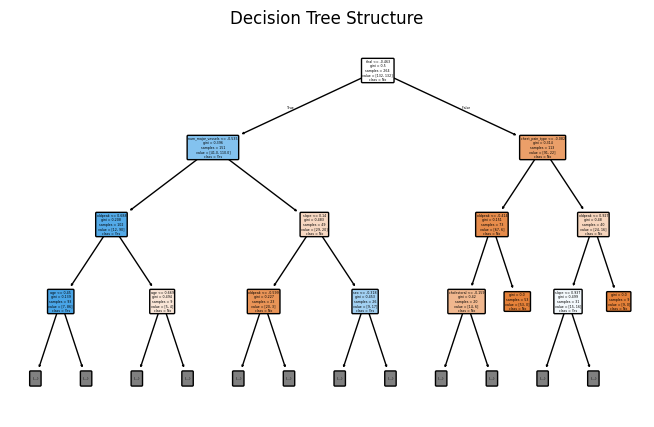

In [27]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
plot_tree(dt_model, max_depth=3, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.title("Decision Tree Structure")

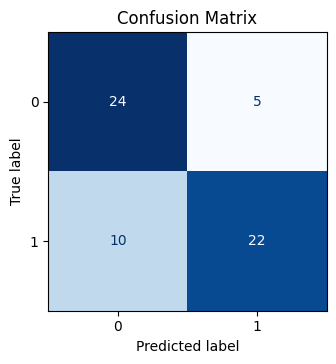

In [28]:
plt.subplot(1, 2, 2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot(ax=plt.gca(), cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## SVM

In [29]:
model_results = []

def evaluate_classifier(model_name, classifier, X_test, y_test):

    predictions = classifier.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print("\nConfusion Matrix")

    cm = confusion_matrix(y_test, predictions)

    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    print("\nClassification Report")
    print(classification_report(y_test, predictions))

    return predictions

Support Vector Machine
Accuracy : 0.8852
Precision: 0.9310
Recall   : 0.8438
F1-Score : 0.8852

Confusion Matrix


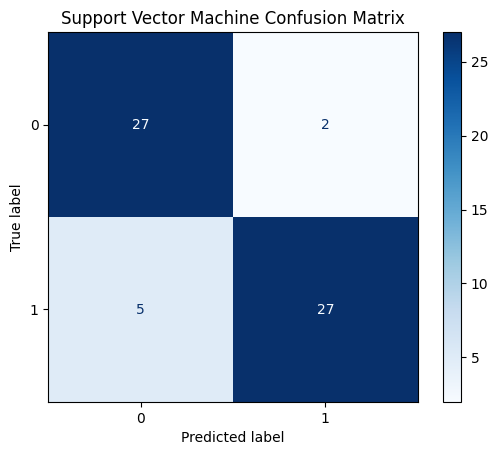


Classification Report
              precision    recall  f1-score   support

           0       0.84      0.93      0.89        29
           1       0.93      0.84      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [30]:
svm_classifier = SVC(
    kernel="rbf",
    random_state=42,
    probability=True
)

svm_classifier.fit(X_train, y_train)

svm_predictions = svm_classifier.predict(X_test)

svm_predictions = evaluate_classifier(
    "Support Vector Machine",
    svm_classifier,
    X_test,
    y_test
)

## KNN

K-Nearest Neighbors
Accuracy : 0.8852
Precision: 0.9310
Recall   : 0.8438
F1-Score : 0.8852

Confusion Matrix


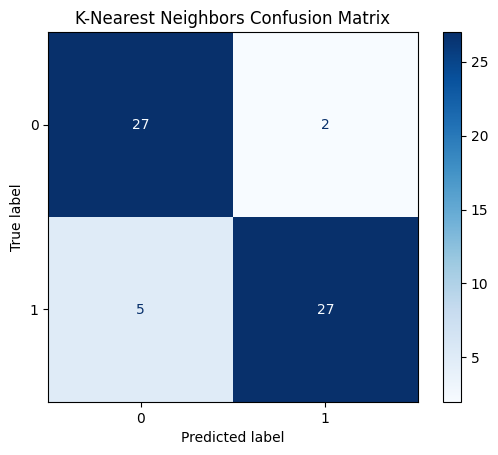


Classification Report
              precision    recall  f1-score   support

           0       0.84      0.93      0.89        29
           1       0.93      0.84      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [31]:
knn_classifier = KNeighborsClassifier(
    n_neighbors=5
)

knn_classifier.fit(X_train, y_train)

knn_predictions = knn_classifier.predict(X_test)

knn_predictions = evaluate_classifier(
    "K-Nearest Neighbors",
    knn_classifier,
    X_test,
    y_test
)

## ensemble

In [32]:
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('dt', dt_model),
        ('svm', svm_classifier),
        ('knn', knn_classifier)],voting='soft')

ensemble_model.fit(X_train, y_train)

y_pred_ensemble = ensemble_model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_ensemble):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ensemble):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ensemble):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_ensemble):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_ensemble))

Accuracy:  0.8689
Precision: 0.9000
Recall:    0.8438
F1-Score:  0.8710
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



## ANN

In [33]:
tf.random.set_seed(42)
ANN_model = Sequential([
    Dense(32, activation='relu',input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

ANN_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)


c:\Users\HP Zbook G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
tf.random.set_seed(42)
history = ANN_model.fit(X_train, y_train,validation_split=0.2,epochs=35,batch_size=32,callbacks=[early_stop],verbose=1)

Epoch 1/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.3839 - loss: 0.7530 - val_accuracy: 0.5849 - val_loss: 0.6799
Epoch 2/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4882 - loss: 0.7209 - val_accuracy: 0.6038 - val_loss: 0.6711
Epoch 3/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5829 - loss: 0.6870 - val_accuracy: 0.5660 - val_loss: 0.6660
Epoch 4/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6066 - loss: 0.6673 - val_accuracy: 0.6038 - val_loss: 0.6630
Epoch 5/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5924 - loss: 0.6613 - val_accuracy: 0.5849 - val_loss: 0.6572
Epoch 6/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6588 - loss: 0.6390 - val_accuracy: 0.6038 - val_loss: 0.6480
Epoch 7/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7109 - loss: 0.6175 - val_accuracy: 0.6038 - val_loss: 0.6358
Epoch 8/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6967 - loss: 0.6157 - val_accuracy: 0.6415 - val_loss: 0.6224


In [35]:
tf.random.set_seed(42)
y_pred_probs = ANN_model.predict(X_test)
y_pred_ANN = (y_pred_probs > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_ANN)
precision = precision_score(y_test, y_pred_ANN)
recall = recall_score(y_test, y_pred_ANN)
f1 = f1_score(y_test, y_pred_ANN)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
 
print("Classification Report:")
print(classification_report(y_test, y_pred_ANN))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Accuracy:  0.8525
Precision: 0.8710
Recall:    0.8438
F1-Score:  0.8571
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [36]:
import pickle

with open('model.pkl', 'wb') as file:
    pickle.dump(svm_classifier, file)

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)